In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor, 
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.base import clone

import catboost as cb
import xgboost as xgb
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Egor\Desktop\VUZ\ML\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df_class = pd.read_csv("MathE_dataset_processed.csv", sep=",", encoding="utf-8")

X_class = df_class.drop(columns=['Type of Answer'])
y_class = df_class['Type of Answer']

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Классификация - размер обучающей выборки:", X_class_train.shape)
print("Классификация - размер тестовой выборки:", X_class_test.shape)

Классификация - размер обучающей выборки: (5970, 186)
Классификация - размер тестовой выборки: (1493, 186)


In [9]:
df_train = pd.read_csv("moldova_train.csv", sep=",", encoding="utf-8")
df_test = pd.read_csv("moldova_test.csv", sep=",", encoding="utf-8")
df_test = df_test.drop(columns=['Transmission_Manual'])
df_test = df_test.drop(columns=['Fuel_type_Diesel'])
df_test = df_test.drop(columns=['Style_Pickup'])
df_train = df_train.drop(columns=['Transmission_Manual'])
df_train = df_train.drop(columns=['Fuel_type_Diesel'])
df_train = df_train.drop(columns=['Style_Pickup'])

X_reg_train = df_train.drop(columns=['Price(euro)'])
y_reg_train = df_train['Price(euro)']

X_reg_test = df_test.drop(columns=['Price(euro)'])
y_reg_test = df_test['Price(euro)']

print("Регрессия - размер обучающей выборки:", X_reg_train.shape)
print("Регрессия - размер тестовой выборки:", X_reg_test.shape)

Регрессия - размер обучающей выборки: (32942, 22)
Регрессия - размер тестовой выборки: (8065, 22)


In [10]:
def print_classification_metrics(y_true, y_pred, y_prob=None, model_name=""):
    print(f"--- Метрики классификации для {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    if y_prob is not None:
        try:
            if len(np.unique(y_true)) == 2:
                print(f"ROC AUC:   {roc_auc_score(y_true, y_prob[:, 1]):.4f}")
            else:
                print(f"ROC AUC:   {roc_auc_score(y_true, y_prob, multi_class='ovr'):.4f}")
        except:
            pass
    print()

def print_regression_metrics(y_true, y_pred, model_name=""):
    print(f"--- Метрики регрессии для {model_name} ---")
    print(f"MSE:  {mean_squared_error(y_true, y_pred):.4f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R2:   {r2_score(y_true, y_pred):.4f}")
    print()

Решающие деревья sklearn

--- Метрики классификации для DecisionTreeClassifier (базовый) ---
Accuracy:  0.5405
Precision: 0.4371
Recall:    0.4995
F1-score:  0.3522
ROC AUC:   0.5225



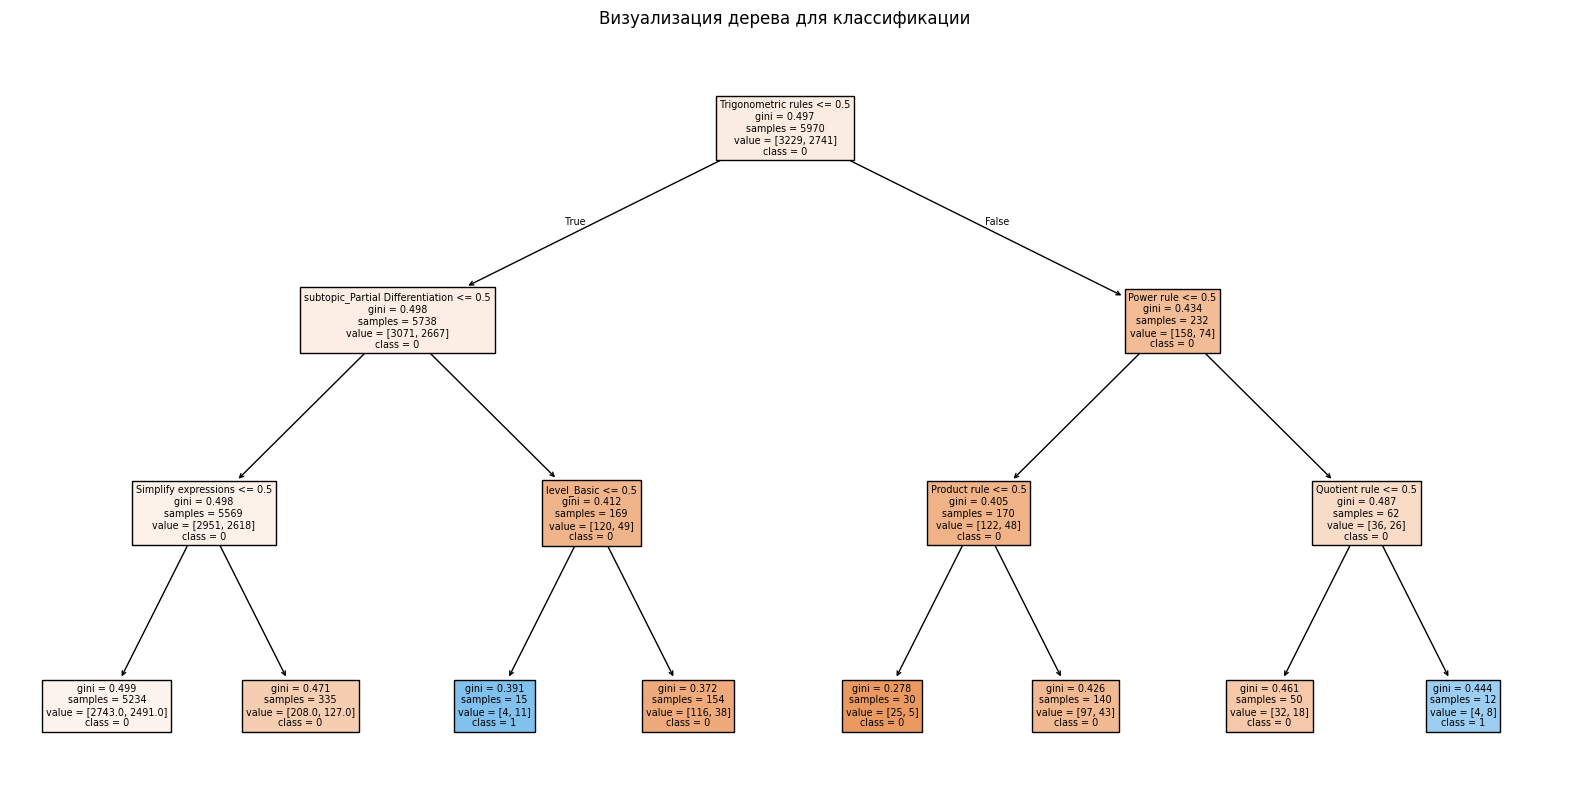

In [12]:
dt_class = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_class.fit(X_class_train, y_class_train)
preds_class = dt_class.predict(X_class_test)
probs_class = dt_class.predict_proba(X_class_test)
print_classification_metrics(y_class_test, preds_class, probs_class, "DecisionTreeClassifier (базовый)")

plt.figure(figsize=(20, 10))
plot_tree(dt_class, filled=True, feature_names=X_class.columns, class_names=[str(c) for c in dt_class.classes_])
plt.title("Визуализация дерева для классификации")
plt.show()


--- Метрики регрессии для DecisionTreeRegressor (базовый) ---
MSE:  55257552.8047
MAE:  4323.9524
RMSE: 7433.5424
R2:   0.5063



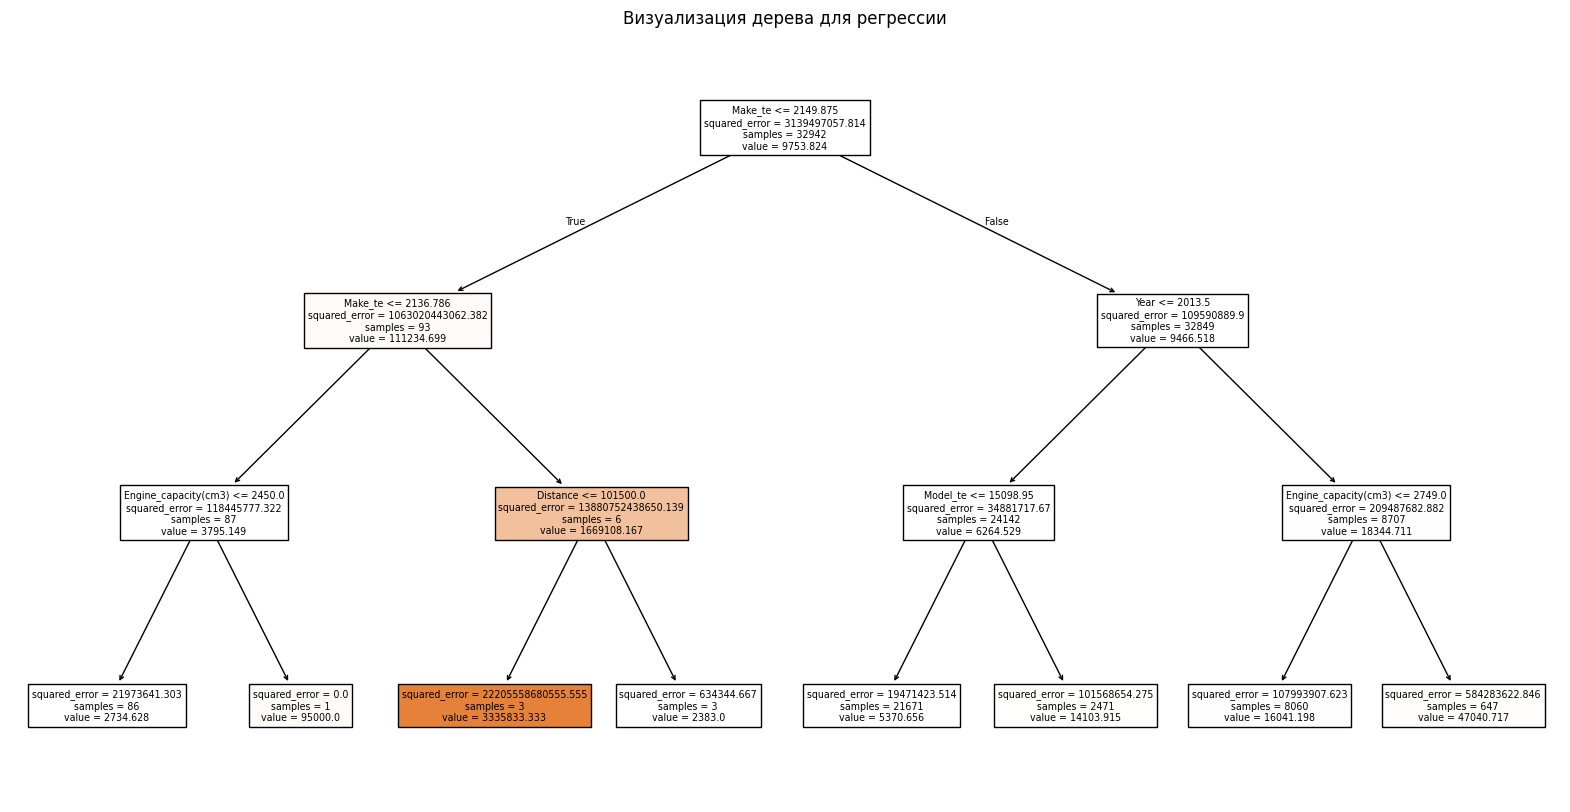

In [13]:
dt_reg = DecisionTreeRegressor(random_state=42, max_depth=3)
dt_reg.fit(X_reg_train, y_reg_train)
preds_reg = dt_reg.predict(X_reg_test)
print_regression_metrics(y_reg_test, preds_reg, "DecisionTreeRegressor (базовый)")

plt.figure(figsize=(20, 10))
plot_tree(dt_reg, filled=True, feature_names=X_reg_train.columns)
plt.title("Визуализация дерева для регрессии")
plt.show()

In [14]:
def objective_dt_class(trial):
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15)
    
    model = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_class_train, y_class_train, cv=cv, scoring='accuracy').mean()
    return score

print("Подбор параметров для DecisionTreeClassifier...")
study_dt_class = optuna.create_study(direction='maximize')
study_dt_class.optimize(objective_dt_class, n_trials=10) # 10 итераций для экономии времени

best_dt_class = DecisionTreeClassifier(**study_dt_class.best_params, random_state=42)
best_dt_class.fit(X_class_train, y_class_train)
print_classification_metrics(y_class_test, best_dt_class.predict(X_class_test), best_dt_class.predict_proba(X_class_test), "DecisionTreeClassifier (Optuna)")


Подбор параметров для DecisionTreeClassifier...
--- Метрики классификации для DecisionTreeClassifier (Optuna) ---
Accuracy:  0.5559
Precision: 0.5523
Recall:    0.5278
F1-score:  0.4789
ROC AUC:   0.5631



In [15]:
def objective_dt_reg(trial):
    max_depth = trial.suggest_int('max_depth', 2, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15)
    
    model = DecisionTreeRegressor(
        max_depth=max_depth, 
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_reg_train, y_reg_train, cv=cv, scoring='neg_mean_squared_error').mean()
    return score

In [16]:
study_dt_reg = optuna.create_study(direction='maximize')
study_dt_reg.optimize(objective_dt_reg, n_trials=10)

best_dt_reg = DecisionTreeRegressor(**study_dt_reg.best_params, random_state=42)
best_dt_reg.fit(X_reg_train, y_reg_train)
print_regression_metrics(y_reg_test, best_dt_reg.predict(X_reg_test), "DecisionTreeRegressor (Optuna)")

--- Метрики регрессии для DecisionTreeRegressor (Optuna) ---
MSE:  23589931.3874
MAE:  2132.3850
RMSE: 4856.9467
R2:   0.7892



In [17]:
def tune_and_evaluate_clf(model_class, param_space, name):
    def obj(trial):
        params = param_space(trial)
        model = model_class(**params, random_state=42)
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        return cross_val_score(model, X_class_train, y_class_train, cv=cv, scoring='accuracy').mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=5)
    best_model = model_class(**study.best_params, random_state=42)
    best_model.fit(X_class_train, y_class_train)
    print_classification_metrics(y_class_test, best_model.predict(X_class_test), getattr(best_model, "predict_proba", lambda x: None)(X_class_test), f"{name} (Optuna)")
    return best_model


In [18]:
def tune_and_evaluate_reg(model_class, param_space, name):
    def obj(trial):
        params = param_space(trial)
        model = model_class(**params, random_state=42)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        return cross_val_score(model, X_reg_train, y_reg_train, cv=cv, scoring='neg_mean_squared_error').mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=5)
    best_model = model_class(**study.best_params, random_state=42)
    best_model.fit(X_reg_train, y_reg_train)
    print_regression_metrics(y_reg_test, best_model.predict(X_reg_test), f"{name} (Optuna)")
    return best_model

In [19]:
def bag_params(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 10, 50)}

def gb_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 2, 7)
    }

In [20]:
print("Обучение Bagging...")
bag_clf = tune_and_evaluate_clf(BaggingClassifier, bag_params, "BaggingClassifier")
bag_reg = tune_and_evaluate_reg(BaggingRegressor, bag_params, "BaggingRegressor")

Обучение Bagging...
--- Метрики классификации для BaggingClassifier (Optuna) ---
Accuracy:  0.5586
Precision: 0.5502
Recall:    0.5431
F1-score:  0.5332
ROC AUC:   0.5651

--- Метрики регрессии для BaggingRegressor (Optuna) ---
MSE:  50898709.5094
MAE:  1882.5607
RMSE: 7134.3332
R2:   0.5453



In [21]:
print("Обучение GradientBoosting...")
gb_clf = tune_and_evaluate_clf(GradientBoostingClassifier, gb_params, "GradientBoostingClassifier")
gb_reg = tune_and_evaluate_reg(GradientBoostingRegressor, gb_params, "GradientBoostingRegressor")

Обучение GradientBoosting...
--- Метрики классификации для GradientBoostingClassifier (Optuna) ---
Accuracy:  0.5606
Precision: 0.5527
Recall:    0.5427
F1-score:  0.5283
ROC AUC:   0.5714

--- Метрики регрессии для GradientBoostingRegressor (Optuna) ---
MSE:  176716012.8697
MAE:  2219.0633
RMSE: 13293.4575
R2:   -0.5788



In [22]:
print("Обучение Stacking...")
stack_clf = StackingClassifier(estimators=[('dt', best_dt_class), ('bag', bag_clf)], final_estimator=LogisticRegression(max_iter=500))
stack_clf.fit(X_class_train, y_class_train)
print_classification_metrics(y_class_test, stack_clf.predict(X_class_test), stack_clf.predict_proba(X_class_test), "StackingClassifier")

Обучение Stacking...
--- Метрики классификации для StackingClassifier ---
Accuracy:  0.5492
Precision: 0.5464
Recall:    0.5159
F1-score:  0.4364
ROC AUC:   0.5725



In [23]:
stack_reg = StackingRegressor(estimators=[('dt', best_dt_reg), ('bag', bag_reg)], final_estimator=Ridge())
stack_reg.fit(X_reg_train, y_reg_train)
print_regression_metrics(y_reg_test, stack_reg.predict(X_reg_test), "StackingRegressor")

--- Метрики регрессии для StackingRegressor ---
MSE:  64212143.6867
MAE:  4844.1350
RMSE: 8013.2480
R2:   0.4263



Специализированные библиотеки

In [24]:
def cb_params(trial):
    return {'iterations': trial.suggest_int('iterations', 50, 150), 'depth': trial.suggest_int('depth', 3, 7), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), 'verbose': 0}

def xgb_params(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 50, 150), 'max_depth': trial.suggest_int('max_depth', 3, 7), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3)}

def lgb_params(trial):
    return {'n_estimators': trial.suggest_int('n_estimators', 50, 150), 'max_depth': trial.suggest_int('max_depth', 3, 7), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), 'verbose': -1}


In [26]:
cb_clf = tune_and_evaluate_clf(cb.CatBoostClassifier, cb_params, "CatBoostClassifier")

0:	learn: 0.6912310	total: 2.46ms	remaining: 344ms
1:	learn: 0.6896531	total: 4.66ms	remaining: 324ms
2:	learn: 0.6885128	total: 6.6ms	remaining: 304ms
3:	learn: 0.6877851	total: 8.49ms	remaining: 291ms
4:	learn: 0.6868063	total: 10.7ms	remaining: 291ms
5:	learn: 0.6861848	total: 12.9ms	remaining: 291ms
6:	learn: 0.6851975	total: 14.8ms	remaining: 284ms
7:	learn: 0.6845600	total: 16.7ms	remaining: 278ms
8:	learn: 0.6841199	total: 19.5ms	remaining: 287ms
9:	learn: 0.6835897	total: 21.7ms	remaining: 284ms
10:	learn: 0.6831961	total: 23.7ms	remaining: 280ms
11:	learn: 0.6828833	total: 25.9ms	remaining: 279ms
12:	learn: 0.6824729	total: 28.9ms	remaining: 285ms
13:	learn: 0.6818235	total: 32.3ms	remaining: 293ms
14:	learn: 0.6813597	total: 42.6ms	remaining: 358ms
15:	learn: 0.6811453	total: 47.2ms	remaining: 369ms
16:	learn: 0.6808961	total: 52.7ms	remaining: 384ms
17:	learn: 0.6805375	total: 54.8ms	remaining: 374ms
18:	learn: 0.6803259	total: 57.8ms	remaining: 371ms
19:	learn: 0.6800092	to

In [27]:
cb_reg = tune_and_evaluate_reg(cb.CatBoostRegressor, cb_params, "CatBoostRegressor")

0:	learn: 52082.7964164	total: 3.8ms	remaining: 236ms
1:	learn: 48444.9878246	total: 7.1ms	remaining: 217ms
2:	learn: 45085.5286230	total: 10.4ms	remaining: 208ms
3:	learn: 41975.4605967	total: 13.2ms	remaining: 194ms
4:	learn: 39103.4779323	total: 16.1ms	remaining: 187ms
5:	learn: 36462.7872068	total: 19.4ms	remaining: 184ms
6:	learn: 34020.7885495	total: 22.2ms	remaining: 178ms
7:	learn: 31764.5258223	total: 24.7ms	remaining: 170ms
8:	learn: 30433.4570941	total: 26.4ms	remaining: 158ms
9:	learn: 29054.1674931	total: 29ms	remaining: 154ms
10:	learn: 26999.1889037	total: 33.5ms	remaining: 158ms
11:	learn: 25218.6414768	total: 37ms	remaining: 157ms
12:	learn: 23593.1318220	total: 41.5ms	remaining: 159ms
13:	learn: 22638.8031549	total: 45.1ms	remaining: 158ms
14:	learn: 21207.2185914	total: 49.7ms	remaining: 159ms
15:	learn: 19785.2522819	total: 52.9ms	remaining: 156ms
16:	learn: 18565.7596123	total: 57.8ms	remaining: 156ms
17:	learn: 17438.0355612	total: 61.4ms	remaining: 153ms
18:	lear

In [28]:
xgb_clf = tune_and_evaluate_clf(xgb.XGBClassifier, xgb_params, "XGBClassifier")

--- Метрики классификации для XGBClassifier (Optuna) ---
Accuracy:  0.5620
Precision: 0.5544
Recall:    0.5437
F1-score:  0.5286
ROC AUC:   0.5780



In [29]:

xgb_reg = tune_and_evaluate_reg(xgb.XGBRegressor, xgb_params, "XGBRegressor")

--- Метрики регрессии для XGBRegressor (Optuna) ---
MSE:  395542698.1496
MAE:  2779.5907
RMSE: 19888.2553
R2:   -2.5338



In [30]:
import re
X_class_train_lgb = X_class_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_class_test_lgb = X_class_test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_reg_train_lgb = X_reg_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_reg_test_lgb = X_reg_test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

In [31]:
def tune_and_evaluate_clf_lgb():
    def obj(trial):
        params = lgb_params(trial)
        model = lgb.LGBMClassifier(**params, random_state=42)
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        return cross_val_score(model, X_class_train_lgb, y_class_train, cv=cv, scoring='accuracy').mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=5)
    best_model = lgb.LGBMClassifier(**study.best_params, random_state=42)
    best_model.fit(X_class_train_lgb, y_class_train)
    print_classification_metrics(y_class_test, best_model.predict(X_class_test_lgb), getattr(best_model, "predict_proba", lambda x: None)(X_class_test_lgb), "LGBMClassifier (Optuna)")


In [32]:
def tune_and_evaluate_reg_lgb():
    def obj(trial):
        params = lgb_params(trial)
        model = lgb.LGBMRegressor(**params, random_state=42)
        cv = KFold(n_splits=3, shuffle=True, random_state=42)
        return cross_val_score(model, X_reg_train_lgb, y_reg_train, cv=cv, scoring='neg_mean_squared_error').mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=5)
    best_model = lgb.LGBMRegressor(**study.best_params, random_state=42)
    best_model.fit(X_reg_train_lgb, y_reg_train)
    print_regression_metrics(y_reg_test, best_model.predict(X_reg_test_lgb), "LGBMRegressor (Optuna)")

In [33]:
tune_and_evaluate_clf_lgb()

--- Метрики классификации для LGBMClassifier (Optuna) ---
Accuracy:  0.5626
Precision: 0.5597
Recall:    0.5378
F1-score:  0.5033
ROC AUC:   0.5800



In [34]:

tune_and_evaluate_reg_lgb()

--- Метрики регрессии для LGBMRegressor (Optuna) ---
MSE:  391157475.0575
MAE:  3007.9856
RMSE: 19777.7015
R2:   -2.4947



In [35]:
class CustomCARTNode:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [36]:
class CustomCART:
    def __init__(self, min_samples_split=2, max_depth=3, task='classification'):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.task = task
        self.root = None

    def fit(self, X, y):
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        y_val = y.values if isinstance(y, pd.Series) else y
        self.root = self._build_tree(X_val, y_val, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if n_samples >= self.min_samples_split and depth <= self.max_depth and len(np.unique(y)) > 1:
            best_split = self._get_best_split(X, y, n_samples, n_features)
            if best_split:
                left_subtree = self._build_tree(best_split['dataset_left'][0], best_split['dataset_left'][1], depth + 1)
                right_subtree = self._build_tree(best_split['dataset_right'][0], best_split['dataset_right'][1], depth + 1)
                return CustomCARTNode(best_split['feature_index'], best_split['threshold'], left_subtree, right_subtree)
        
        leaf_value = self._calculate_leaf_value(y)
        return CustomCARTNode(value=leaf_value)

    def _get_best_split(self, X, y, n_samples, n_features):
        best_split = {}
        best_gain = -float("inf") if self.task == 'classification' else float("inf")
        
        # Для ускорения выбираем только часть фичей и случайные пороги (работает быстрее на больших данных)
        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            unique_vals = np.unique(feature_values)
            if len(unique_vals) > 10:
                possible_thresholds = np.percentile(unique_vals, np.linspace(10, 90, 9))
            else:
                possible_thresholds = unique_vals
                
            for threshold in possible_thresholds:
                dataset_left, dataset_right = self._split(X, y, feature_index, threshold)
                if len(dataset_left[0]) > 0 and len(dataset_right[0]) > 0:
                    if self.task == 'classification':
                        gain = self._information_gain(y, dataset_left[1], dataset_right[1])
                        if gain > best_gain:
                            best_split = {'feature_index': feature_index, 'threshold': threshold, 'dataset_left': dataset_left, 'dataset_right': dataset_right}
                            best_gain = gain
                    else:
                        mse = self._mse_split(y, dataset_left[1], dataset_right[1])
                        if mse < best_gain:
                            best_split = {'feature_index': feature_index, 'threshold': threshold, 'dataset_left': dataset_left, 'dataset_right': dataset_right}
                            best_gain = mse
        return best_split

    def _split(self, X, y, feature_index, threshold):
        left_idxs = np.argwhere(X[:, feature_index] <= threshold).flatten()
        right_idxs = np.argwhere(X[:, feature_index] > threshold).flatten()
        return (X[left_idxs], y[left_idxs]), (X[right_idxs], y[right_idxs])

    def _information_gain(self, parent, l_child, r_child):
        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        gain = self._gini(parent) - (weight_l * self._gini(l_child) + weight_r * self._gini(r_child))
        return gain

    def _gini(self, y):
        class_labels = np.unique(y)
        gini = 1
        for cls in class_labels:
            p_cls = len(y[y == cls]) / len(y)
            gini -= p_cls ** 2
        return gini

    def _mse_split(self, parent, l_child, r_child):
        weight_l = len(l_child) / len(parent)
        weight_r = len(r_child) / len(parent)
        mse = weight_l * np.var(l_child) + weight_r * np.var(r_child)
        return mse

    def _calculate_leaf_value(self, y):
        if self.task == 'classification':
            y_list = list(y)
            return max(set(y_list), key=y_list.count)
        else:
            return np.mean(y)

    def predict(self, X):
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        return np.array([self._make_prediction(x, self.root) for x in X_val])

    def _make_prediction(self, x, tree):
        if tree.value is not None:
            return tree.value
        feature_val = x[tree.feature_index]
        if feature_val <= tree.threshold:
            return self._make_prediction(x, tree.left)
        else:
            return self._make_prediction(x, tree.right)

In [39]:
custom_cart_clf = CustomCART(max_depth=3, task='classification')
custom_cart_clf.fit(X_class_train, y_class_train)
preds_custom_clf = custom_cart_clf.predict(X_class_test)
print_classification_metrics(y_class_test, preds_custom_clf, model_name="Custom CART Classifier")

--- Метрики классификации для Custom CART Classifier ---
Accuracy:  0.5466
Precision: 0.5508
Recall:    0.5094
F1-score:  0.4010



In [38]:
custom_cart_reg = CustomCART(max_depth=3, task='regression')
custom_cart_reg.fit(X_reg_train, y_reg_train)
preds_custom_reg = custom_cart_reg.predict(X_reg_test)
print_regression_metrics(y_reg_test, preds_custom_reg, model_name="Custom CART Regressor")

--- Метрики регрессии для Custom CART Regressor ---
MSE:  50651573.3774
MAE:  3534.8570
RMSE: 7116.9919
R2:   0.5475



In [40]:
class CustomBagging:
    def __init__(self, base_estimator, n_estimators=10, task='classification'):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.task = task
        self.models = []

    def fit(self, X, y):
        self.models = []
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        y_val = y.values if isinstance(y, pd.Series) else y
        n_samples = X_val.shape[0]
        
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X_val[indices], y_val[indices]
            
            model = clone(self.base_estimator)
            model.fit(X_boot, y_boot)
            self.models.append(model)
        return self

    def predict(self, X):
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        preds = np.column_stack([model.predict(X_val) for model in self.models])
        
        if self.task == 'classification':
            # Мажоритарное голосование
            res = []
            for row in preds:
                vals, counts = np.unique(row, return_counts=True)
                res.append(vals[np.argmax(counts)])
            return np.array(res)
        else:
            # Усреднение
            return np.mean(preds, axis=1)

In [43]:
class CustomStacking:
    def __init__(self, base_estimators, meta_estimator, task='classification'):
        self.base_estimators = base_estimators
        self.meta_estimator = meta_estimator
        self.task = task

    def fit(self, X, y):
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        y_val = y.values if isinstance(y, pd.Series) else y
        n_samples = X_val.shape[0]
        
        if self.task == 'classification':
            kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            splits = kf.split(X_val, y_val)
        else:
            kf = KFold(n_splits=3, shuffle=True, random_state=42)
            splits = kf.split(X_val)
            
        meta_features = np.zeros((n_samples, len(self.base_estimators)))
        
        # Получение OOF предсказаний
        for train_idx, val_idx in splits:
            X_tr, y_tr = X_val[train_idx], y_val[train_idx]
            X_v = X_val[val_idx]
            
            for i, model in enumerate(self.base_estimators):
                cloned = clone(model)
                cloned.fit(X_tr, y_tr)
                meta_features[val_idx, i] = cloned.predict(X_v)
                
        # Обучение на всех данных
        for model in self.base_estimators:
            model.fit(X_val, y_val)
            
        # Обучение мета-модели
        self.meta_estimator.fit(meta_features, y_val)
        return self

    def predict(self, X):
        X_val = X.values if isinstance(X, pd.DataFrame) else X
        meta_features = np.column_stack([model.predict(X_val) for model in self.base_estimators])
        return self.meta_estimator.predict(meta_features)

In [44]:
c_bag_clf = CustomBagging(base_estimator=DecisionTreeClassifier(max_depth=5, random_state=42), n_estimators=10, task='classification')
c_bag_clf.fit(X_class_train, y_class_train)
print_classification_metrics(y_class_test, c_bag_clf.predict(X_class_test), model_name="Custom Bagging Classifier")


--- Метрики классификации для Custom Bagging Classifier ---
Accuracy:  0.5466
Precision: 0.5508
Recall:    0.5094
F1-score:  0.4010



In [45]:
c_bag_reg = CustomBagging(base_estimator=DecisionTreeRegressor(max_depth=5, random_state=42), n_estimators=10, task='regression')
c_bag_reg.fit(X_reg_train, y_reg_train)
print_regression_metrics(y_reg_test, c_bag_reg.predict(X_reg_test), model_name="Custom Bagging Regressor")


--- Метрики регрессии для Custom Bagging Regressor ---
MSE:  151796720.9604
MAE:  2685.3769
RMSE: 12320.5812
R2:   -0.3562



In [46]:
c_stack_clf = CustomStacking(
    base_estimators=[DecisionTreeClassifier(max_depth=3, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42)],
    meta_estimator=LogisticRegression(),
    task='classification'
)
c_stack_clf.fit(X_class_train, y_class_train)
print_classification_metrics(y_class_test, c_stack_clf.predict(X_class_test), model_name="Custom Stacking Classifier")


--- Метрики классификации для Custom Stacking Classifier ---
Accuracy:  0.5479
Precision: 0.5534
Recall:    0.5114
F1-score:  0.4089



In [47]:
c_stack_reg = CustomStacking(
    base_estimators=[DecisionTreeRegressor(max_depth=3, random_state=42), DecisionTreeRegressor(max_depth=5, random_state=42)],
    meta_estimator=Ridge(),
    task='regression'
)
c_stack_reg.fit(X_reg_train, y_reg_train)
print_regression_metrics(y_reg_test, c_stack_reg.predict(X_reg_test), model_name="Custom Stacking Regressor")



--- Метрики регрессии для Custom Stacking Regressor ---
MSE:  33496900.7736
MAE:  3107.9630
RMSE: 5787.6507
R2:   0.7007

